# No normalization

FITS columns and units:
  Energies: keV
  TimeTags: s
  Xpointings (glon,glat): rad
  Ypointings (glon,glat): rad
  Zpointings (glon,glat): rad
  Phi: rad
  Chi local: rad
  Psi local: rad
  Distance: cm
  Chi galactic: deg
  Psi galactic: deg
  Compton Seq: None

Event diagnostics
-----------------
Total FITS events:    72363
Selected events:      2568
Rejected events:      69795
Selected time range: 1464591827.029988 -- 1464591837.985173
Phi range [deg]: 5.716 -- 176.930
Chi Galactic range [deg]: 0.040 -- 359.878
Psi Galactic range [deg]: -87.223 -- 86.396
Axis norm range: 1.000000000000 -- 1.000000000000

Backprojection with sigma_ARM = 3.0 deg
Backprojection maximum: l=244.687 deg, b=-1.194 deg
Angular separation from true position: 2.049 deg
Maximum map value:       200.183690
Map value at true pixel: 198.272783
True/max ratio:          0.990454


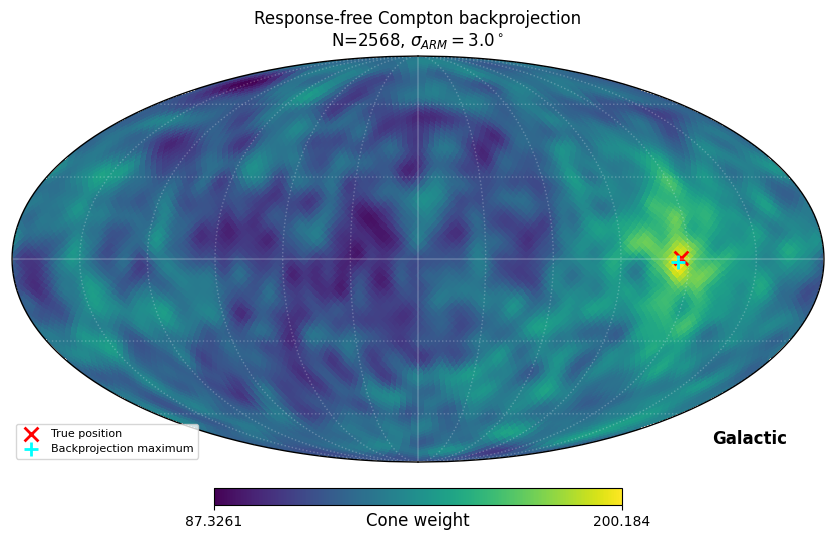


Backprojection with sigma_ARM = 5.0 deg
Backprojection maximum: l=244.687 deg, b=-1.194 deg
Angular separation from true position: 2.049 deg
Maximum map value:       309.496519
Map value at true pixel: 309.171318
True/max ratio:          0.998949


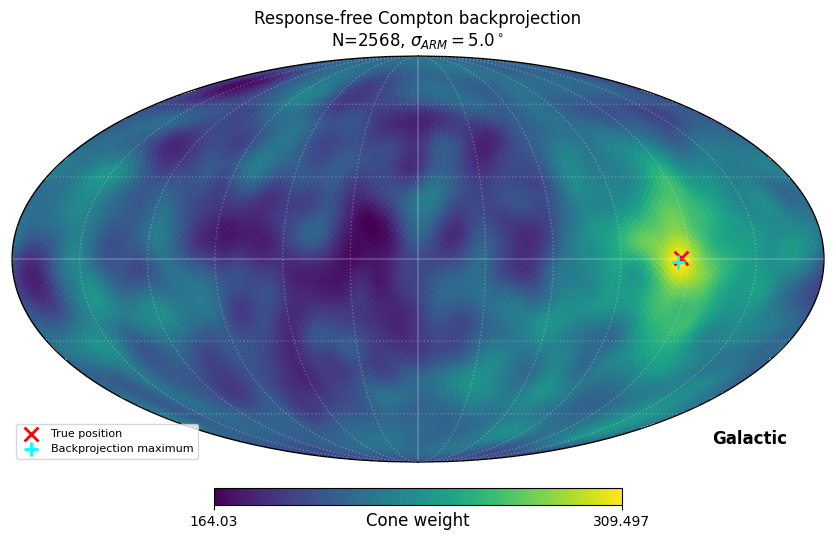


Backprojection with sigma_ARM = 10.0 deg
Backprojection maximum: l=243.281 deg, b=0.000 deg
Angular separation from true position: 0.417 deg
Maximum map value:       557.640158
Map value at true pixel: 557.640158
True/max ratio:          1.000000


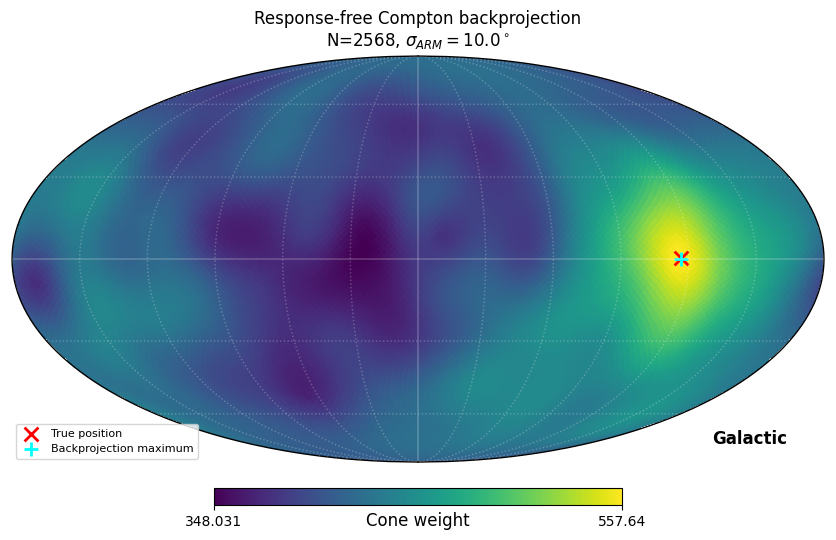

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

import astropy.units as u
from astropy.io import fits
from astropy.coordinates import SkyCoord


# ============================================================
# User configuration
# ============================================================

FITS_FILE = "GRB165030A_unbinned_with_ori.fits.gz"

# Andreas 使用的 GRB 时间范围
TMIN = 1464591827.0
TMAX = 1464591838.0

# Published COSI localization
TRUE_L = 243.4
TRUE_B = 0.4

# NSIDE=32 gives a pixel size of about 1.8 degrees.
# Start with 32. Increase to 64 after confirming that the code works.
NSIDE = 32

# The output map is generated in NESTED ordering.
NEST = True

# Try several smoothing widths.
# This is only the width used to draw the Compton cones.
SIGMA_DEG_LIST = [3.0, 5.0, 10.0]

# Number of sky pixels processed at once.
# Reduce this if memory usage is too high.
CHUNK_SIZE = 256

# Save PNG files in addition to displaying them.
SAVE_PLOTS = False


# ============================================================
# Read the unbinned FITS file
# ============================================================

def read_unbinned_fits(fits_file):
    """
    Read the fields required for response-free backprojection.

    Expected units:
        TimeTags        : s
        Phi             : rad
        Chi galactic    : deg
        Psi galactic    : deg
    """

    with fits.open(fits_file, memmap=True) as hdul:
        table = hdul[1].data

        print("FITS columns and units:")
        for column in hdul[1].columns:
            print(f"  {column.name}: {column.unit}")

        time = np.asarray(
            table["TimeTags"],
            dtype=np.float64,
        )

        phi = np.asarray(
            table["Phi"],
            dtype=np.float64,
        )

        chi_gal = np.asarray(
            table["Chi galactic"],
            dtype=np.float64,
        )

        psi_gal = np.asarray(
            table["Psi galactic"],
            dtype=np.float64,
        )

    return {
        "time": time,
        "phi": phi,
        "chi_gal": chi_gal,
        "psi_gal": psi_gal,
    }


# ============================================================
# Select events
# ============================================================

def select_events(data, tmin=None, tmax=None):
    """
    Select finite, physically valid Compton events.

    The time interval is half-open:
        tmin <= time < tmax
    """

    time = data["time"]
    phi = data["phi"]
    chi_gal = data["chi_gal"]
    psi_gal = data["psi_gal"]

    mask = (
        np.isfinite(time)
        & np.isfinite(phi)
        & np.isfinite(chi_gal)
        & np.isfinite(psi_gal)
        & (phi >= 0.0)
        & (phi <= np.pi)
        & (psi_gal >= -90.0)
        & (psi_gal <= 90.0)
    )

    if tmin is not None:
        mask &= time >= tmin

    if tmax is not None:
        mask &= time < tmax

    selected = {
        "time": time[mask],
        "phi": phi[mask],
        "chi_gal": chi_gal[mask],
        "psi_gal": psi_gal[mask],
    }

    return selected, mask


# ============================================================
# Convert Galactic lon/lat to Cartesian unit vectors
# ============================================================

def galactic_lonlat_to_vectors(l_deg, b_deg):
    """
    Convert Galactic longitude and latitude to Cartesian unit vectors.

    Parameters
    ----------
    l_deg : array-like
        Galactic longitude in degrees.
    b_deg : array-like
        Galactic latitude in degrees.

    Returns
    -------
    vectors : ndarray, shape (N, 3)
        Galactic Cartesian unit vectors.
    """

    l_rad = np.deg2rad(l_deg)
    b_rad = np.deg2rad(b_deg)

    cos_b = np.cos(b_rad)

    vectors = np.column_stack(
        (
            cos_b * np.cos(l_rad),
            cos_b * np.sin(l_rad),
            np.sin(b_rad),
        )
    )

    return vectors


# ============================================================
# Response-free Compton-cone backprojection
# ============================================================

def cone_backprojection(
    axis_xyz,
    phi_rad,
    *,
    nside=32,
    nest=True,
    sigma_deg=5.0,
    chunk_size=256,
):
    """
    Generate a response-free Compton-cone backprojection.

    For event i and sky pixel j:

        ARM_ij = angular_separation(axis_i, sky_j) - phi_i

    The event contributes:

        exp[-0.5 * (ARM_ij / sigma)^2]

    Parameters
    ----------
    axis_xyz : ndarray, shape (Nevents, 3)
        Measured Compton-axis directions in Galactic Cartesian
        coordinates.

    phi_rad : ndarray, shape (Nevents,)
        Kinematic Compton scatter angles in radians.

    nside : int
        HEALPix NSIDE of the output image.

    nest : bool
        If True, use NESTED HEALPix ordering.

    sigma_deg : float
        Gaussian ARM kernel width in degrees.

    chunk_size : int
        Number of sky pixels processed simultaneously.

    Returns
    -------
    image : ndarray
        HEALPix backprojection map.
    """

    axis_xyz = np.asarray(axis_xyz, dtype=np.float64)
    phi_rad = np.asarray(phi_rad, dtype=np.float64)

    if axis_xyz.ndim != 2 or axis_xyz.shape[1] != 3:
        raise ValueError(
            "axis_xyz must have shape (Nevents, 3)"
        )

    if len(axis_xyz) != len(phi_rad):
        raise ValueError(
            "axis_xyz and phi_rad must contain the same number of events"
        )

    if len(phi_rad) == 0:
        raise ValueError("No events were supplied")

    # Normalize the measured event-axis vectors.
    axis_norm = np.linalg.norm(
        axis_xyz,
        axis=1,
        keepdims=True,
    )

    valid_axis = (
        np.isfinite(axis_norm[:, 0])
        & (axis_norm[:, 0] > 0.0)
    )

    axis_xyz = axis_xyz[valid_axis]
    phi_rad = phi_rad[valid_axis]
    axis_norm = axis_norm[valid_axis]

    axis_xyz = axis_xyz / axis_norm

    npix = hp.nside2npix(nside)
    pixels = np.arange(npix, dtype=np.int64)

    # Cartesian directions of the output HEALPix pixels.
    sky_xyz = np.column_stack(
        hp.pix2vec(
            nside,
            pixels,
            nest=nest,
        )
    )

    sigma_rad = np.deg2rad(sigma_deg)

    if sigma_rad <= 0.0:
        raise ValueError("sigma_deg must be greater than zero")

    image = np.zeros(npix, dtype=np.float64)

    for start in range(0, npix, chunk_size):
        stop = min(start + chunk_size, npix)

        # Shape:
        #     (number of pixels in chunk, number of events)
        cos_separation = sky_xyz[start:stop] @ axis_xyz.T

        cos_separation = np.clip(
            cos_separation,
            -1.0,
            1.0,
        )

        separation = np.arccos(cos_separation)

        # phi_rad is broadcast over all sky pixels.
        arm = separation - phi_rad[None, :]

        weights = np.exp(
            -0.5 * (arm / sigma_rad) ** 2
        )

        image[start:stop] = np.sum(
            weights,
            axis=1,
        )

    return image


# ============================================================
# Diagnostics
# ============================================================

def print_event_diagnostics(all_data, selected_data):
    """
    Print basic checks on the selected events.
    """

    n_total = len(all_data["time"])
    n_selected = len(selected_data["time"])

    print()
    print("Event diagnostics")
    print("-----------------")
    print(f"Total FITS events:    {n_total}")
    print(f"Selected events:      {n_selected}")
    print(f"Rejected events:      {n_total - n_selected}")

    if n_selected == 0:
        raise RuntimeError(
            "No events survived the selection"
        )

    time = selected_data["time"]
    phi = selected_data["phi"]
    chi_gal = selected_data["chi_gal"]
    psi_gal = selected_data["psi_gal"]

    print(
        "Selected time range: "
        f"{time.min():.6f} -- {time.max():.6f}"
    )

    print(
        "Phi range [deg]: "
        f"{np.rad2deg(phi.min()):.3f} -- "
        f"{np.rad2deg(phi.max()):.3f}"
    )

    print(
        "Chi Galactic range [deg]: "
        f"{chi_gal.min():.3f} -- "
        f"{chi_gal.max():.3f}"
    )

    print(
        "Psi Galactic range [deg]: "
        f"{psi_gal.min():.3f} -- "
        f"{psi_gal.max():.3f}"
    )

    axis_xyz = galactic_lonlat_to_vectors(
        chi_gal,
        psi_gal,
    )

    norms = np.linalg.norm(axis_xyz, axis=1)

    print(
        "Axis norm range: "
        f"{norms.min():.12f} -- "
        f"{norms.max():.12f}"
    )


# ============================================================
# Find and report the map maximum
# ============================================================

def report_map_result(
    image,
    *,
    nside,
    nest,
    true_l,
    true_b,
):
    """
    Find the map maximum and compare it with the true position.
    """

    best_pixel = int(np.argmax(image))

    best_l, best_b = hp.pix2ang(
        nside,
        best_pixel,
        nest=nest,
        lonlat=True,
    )

    true_coord = SkyCoord(
        l=true_l * u.deg,
        b=true_b * u.deg,
        frame="galactic",
    )

    best_coord = SkyCoord(
        l=best_l * u.deg,
        b=best_b * u.deg,
        frame="galactic",
    )

    separation = true_coord.separation(
        best_coord
    ).deg

    true_pixel = hp.ang2pix(
        nside,
        true_l,
        true_b,
        nest=nest,
        lonlat=True,
    )

    print(
        f"Backprojection maximum: "
        f"l={best_l:.3f} deg, "
        f"b={best_b:.3f} deg"
    )

    print(
        f"Angular separation from true position: "
        f"{separation:.3f} deg"
    )

    print(
        f"Maximum map value:       "
        f"{image[best_pixel]:.6f}"
    )

    print(
        f"Map value at true pixel: "
        f"{image[true_pixel]:.6f}"
    )

    print(
        f"True/max ratio:          "
        f"{image[true_pixel] / image[best_pixel]:.6f}"
    )

    return {
        "best_pixel": best_pixel,
        "best_l": best_l,
        "best_b": best_b,
        "separation_deg": separation,
        "true_pixel": true_pixel,
    }


# ============================================================
# Plot the result
# ============================================================

def plot_backprojection(
    image,
    result,
    *,
    nside,
    nest,
    sigma_deg,
    n_events,
    true_l,
    true_b,
    save_plot=False,
):
    """
    Plot the response-free Galactic backprojection.
    """

    hp.mollview(
        image,
        nest=nest,
        coord="G",
        title=(
            "Response-free Compton backprojection\n"
            f"N={n_events}, "
            rf"$\sigma_{{ARM}}={sigma_deg:.1f}^\circ$"
        ),
        unit="Cone weight",
        cmap="viridis",
    )

    hp.graticule(
        dpar=30,
        dmer=30,
        color="white",
        alpha=0.25,
    )

    # Published source position
    hp.projscatter(
        true_l,
        true_b,
        lonlat=True,
        coord="G",
        marker="x",
        color="red",
        s=100,
        linewidths=2,
        label="True position",
    )

    # Backprojection maximum
    hp.projscatter(
        result["best_l"],
        result["best_b"],
        lonlat=True,
        coord="G",
        marker="+",
        color="cyan",
        s=100,
        linewidths=2,
        label="Backprojection maximum",
    )

    plt.legend(
        loc="lower left",
        fontsize=8,
    )

    if save_plot:
        output_name = (
            f"backprojection_sigma_"
            f"{sigma_deg:g}deg.png"
        )

        plt.savefig(
            output_name,
            dpi=200,
            bbox_inches="tight",
        )

        print(f"Saved: {output_name}")

    plt.show()
    plt.close()


# ============================================================
# Main program
# ============================================================

def main():
    data = read_unbinned_fits(FITS_FILE)

    selected, mask = select_events(
        data,
        tmin=TMIN,
        tmax=TMAX,
    )

    print_event_diagnostics(
        data,
        selected,
    )

    # Chi galactic = Galactic longitude in degrees
    # Psi galactic = Galactic latitude in degrees
    axis_xyz = galactic_lonlat_to_vectors(
        selected["chi_gal"],
        selected["psi_gal"],
    )

    phi_rad = selected["phi"]

    for sigma_deg in SIGMA_DEG_LIST:
        print()
        print("=" * 70)
        print(
            f"Backprojection with sigma_ARM = "
            f"{sigma_deg:.1f} deg"
        )
        print("=" * 70)

        image = cone_backprojection(
            axis_xyz,
            phi_rad,
            nside=NSIDE,
            nest=NEST,
            sigma_deg=sigma_deg,
            chunk_size=CHUNK_SIZE,
        )

        result = report_map_result(
            image,
            nside=NSIDE,
            nest=NEST,
            true_l=TRUE_L,
            true_b=TRUE_B,
        )

        plot_backprojection(
            image,
            result,
            nside=NSIDE,
            nest=NEST,
            sigma_deg=sigma_deg,
            n_events=len(phi_rad),
            true_l=TRUE_L,
            true_b=TRUE_B,
            save_plot=SAVE_PLOTS,
        )


if __name__ == "__main__":
    main()

# Normalization

Event diagnostics
-----------------
Total FITS events:    72363
Selected events:      2568
Rejected events:      69795
Selected time range: 1464591827.029988 -- 1464591837.985173
Phi range [deg]: 5.716 -- 176.930
Axis norm range: 1.000000000000 -- 1.000000000000

Normalized backprojection with sigma_ARM = 3.0 deg
Maximum:                       l=244.687, b=-1.194 deg
Separation from true position: 2.049 deg
Maximum map value:             0.322200124548
Map value at true pixel:       0.316988640376
True/max ratio:                0.983825
Sum of all map pixels:         2568.000000000000
Expected map sum:              2568.000000000000
Map-sum residual:              +0.000000e+00
Event normalization range:     46.521302 -- 805.360068


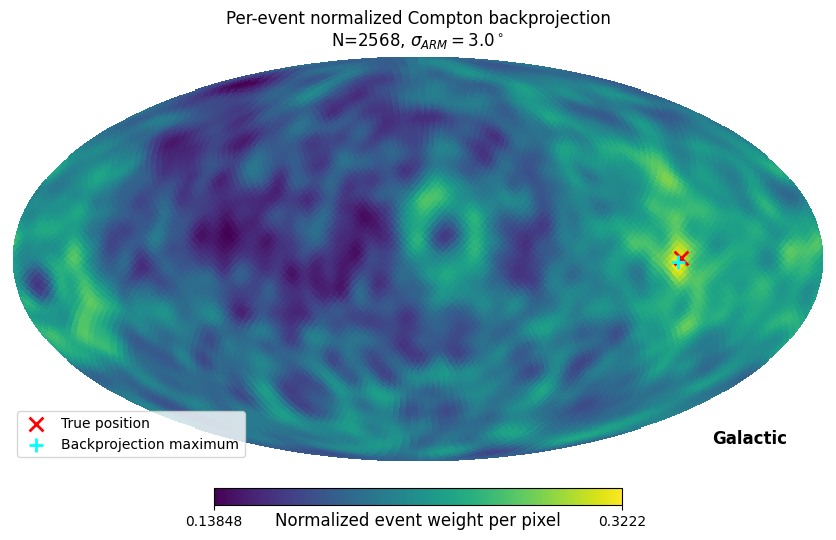

Saved HEALPix map:             /project/majello/astrohe/yong/COSI/Balloon_Data/Andreas_Data/BindData/normalized_gaussian_arm_sigma_3_deg.fits
Saved figure:                  /project/majello/astrohe/yong/COSI/Balloon_Data/Andreas_Data/BindData/normalized_gaussian_arm_sigma_3_deg.png

Normalized backprojection with sigma_ARM = 5.0 deg
Maximum:                       l=244.687, b=-1.194 deg
Separation from true position: 2.049 deg
Maximum map value:             0.295680704418
Map value at true pixel:       0.294946340562
True/max ratio:                0.997516
Sum of all map pixels:         2568.000000000000
Expected map sum:              2568.000000000000
Map-sum residual:              +0.000000e+00
Event normalization range:     91.032990 -- 1338.967531


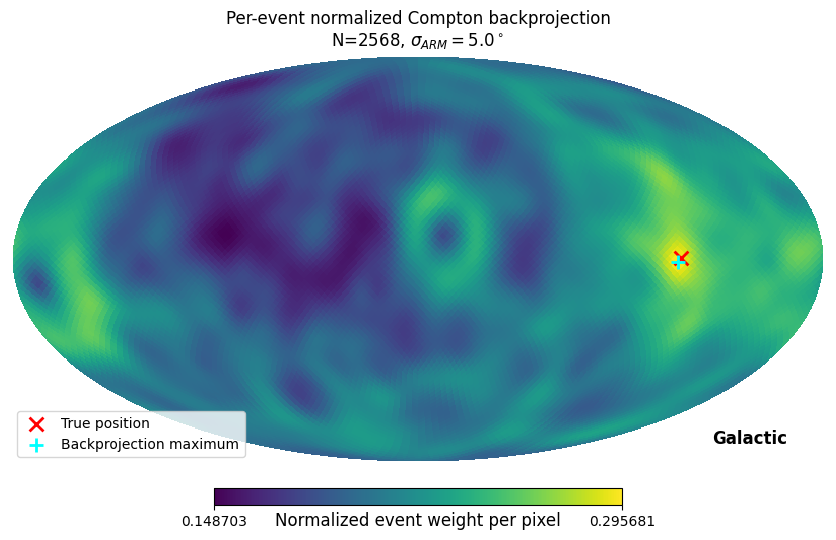

Saved HEALPix map:             /project/majello/astrohe/yong/COSI/Balloon_Data/Andreas_Data/BindData/normalized_gaussian_arm_sigma_5_deg.fits
Saved figure:                  /project/majello/astrohe/yong/COSI/Balloon_Data/Andreas_Data/BindData/normalized_gaussian_arm_sigma_5_deg.png

Normalized backprojection with sigma_ARM = 10.0 deg
Maximum:                       l=243.281, b=2.388 deg
Separation from true position: 1.992 deg
Maximum map value:             0.267291268165
Map value at true pixel:       0.267081651624
True/max ratio:                0.999216
Sum of all map pixels:         2568.000000000000
Expected map sum:              2568.000000000000
Map-sum residual:              +0.000000e+00
Event normalization range:     264.672542 -- 2647.487764


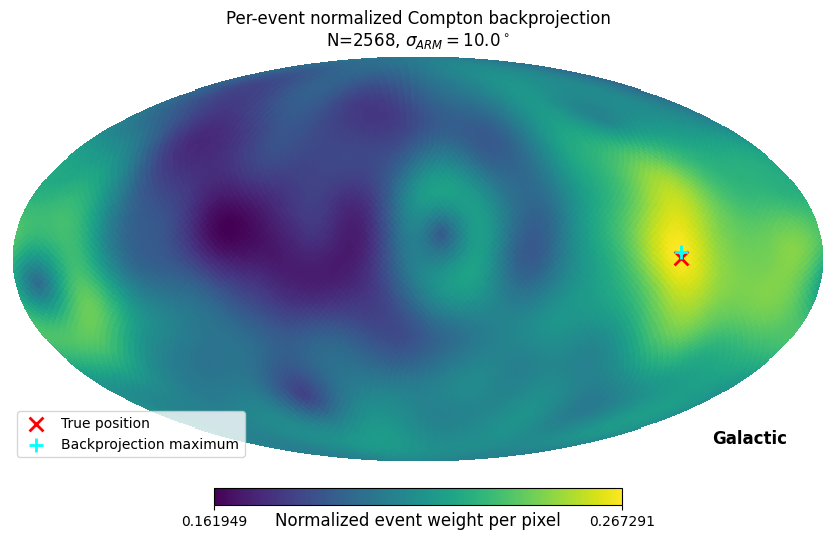

Saved HEALPix map:             /project/majello/astrohe/yong/COSI/Balloon_Data/Andreas_Data/BindData/normalized_gaussian_arm_sigma_10_deg.fits
Saved figure:                  /project/majello/astrohe/yong/COSI/Balloon_Data/Andreas_Data/BindData/normalized_gaussian_arm_sigma_10_deg.png


In [2]:
#!/usr/bin/env python3
"""Per-event normalized Gaussian-ARM Compton backprojection.

Each event first produces an unnormalized kernel on the HEALPix grid:

    raw_K[i, j] = exp[-0.5 * (ARM[i, j] / sigma_ARM)**2]

It is then normalized over all sky pixels:

    K[i, j] = raw_K[i, j] / sum_j raw_K[i, j]

Consequently, each event contributes total map weight 1 and the final map sum
is the number of selected events (up to floating-point round-off).

This is a response-free diagnostic map. It is not a Poisson likelihood and it
does not contain detector efficiency or a background model.
"""

from pathlib import Path

import astropy.units as u
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
from astropy.io import fits


# -----------------------------------------------------------------------------
# User configuration
# -----------------------------------------------------------------------------

FITS_FILE = Path("GRB165030A_unbinned.fits.gz")

TMIN = 1464591827.0
TMAX = 1464591838.0

TRUE_L_DEG = 243.4
TRUE_B_DEG = 0.4

NSIDE = 32
NEST = True
SIGMA_ARM_DEG_LIST = [3.0, 5.0, 10.0]

# Number of HEALPix pixels processed at once. Increasing it can be faster but
# requires more memory because the temporary array has shape
# (PIXEL_CHUNK_SIZE, N_events).
PIXEL_CHUNK_SIZE = 256

OUTPUT_DIRECTORY = Path(".")


# -----------------------------------------------------------------------------
# Geometry and input
# -----------------------------------------------------------------------------

def galactic_lonlat_to_vectors(l_deg, b_deg):
    """Convert Galactic longitude/latitude in degrees to Cartesian vectors."""
    l_rad = np.deg2rad(np.asarray(l_deg, dtype=np.float64))
    b_rad = np.deg2rad(np.asarray(b_deg, dtype=np.float64))
    cos_b = np.cos(b_rad)

    return np.column_stack(
        (
            cos_b * np.cos(l_rad),
            cos_b * np.sin(l_rad),
            np.sin(b_rad),
        )
    )


def read_selected_events(fits_file, tmin, tmax):
    """Read the cosipy unbinned FITS and select the GRB time interval."""
    with fits.open(fits_file, memmap=True) as hdul:
        table = hdul[1].data

        time = np.asarray(table["TimeTags"], dtype=np.float64)
        phi = np.asarray(table["Phi"], dtype=np.float64)
        chi_gal = np.asarray(table["Chi galactic"], dtype=np.float64)
        psi_gal = np.asarray(table["Psi galactic"], dtype=np.float64)

    mask = (
        (time >= tmin)
        & (time < tmax)
        & np.isfinite(phi)
        & np.isfinite(chi_gal)
        & np.isfinite(psi_gal)
        & (phi >= 0.0)
        & (phi <= np.pi)
        & (psi_gal >= -90.0)
        & (psi_gal <= 90.0)
    )

    axis_xyz = galactic_lonlat_to_vectors(chi_gal[mask], psi_gal[mask])
    axis_xyz /= np.linalg.norm(axis_xyz, axis=1, keepdims=True)

    return {
        "total_count": len(time),
        "time": time[mask],
        "phi": phi[mask],
        "chi_gal": chi_gal[mask],
        "psi_gal": psi_gal[mask],
        "axis_xyz": axis_xyz,
    }


def make_sky_vectors(nside, nest):
    """Return all HEALPix pixel-center unit vectors."""
    pixels = np.arange(hp.nside2npix(nside), dtype=np.int64)
    return np.column_stack(hp.pix2vec(nside, pixels, nest=nest))


def gaussian_arm_weights(sky_xyz_chunk, axis_xyz, phi_rad, sigma_rad):
    """Return raw Gaussian ARM weights for one pixel chunk and all events."""
    cos_separation = sky_xyz_chunk @ axis_xyz.T
    cos_separation = np.clip(cos_separation, -1.0, 1.0)

    separation = np.arccos(cos_separation)
    arm = separation - phi_rad[None, :]

    return np.exp(-0.5 * (arm / sigma_rad) ** 2)


# -----------------------------------------------------------------------------
# Per-event normalized backprojection
# -----------------------------------------------------------------------------

def normalized_gaussian_arm_backprojection(
    axis_xyz,
    phi_rad,
    *,
    nside=32,
    nest=True,
    sigma_arm_deg=5.0,
    pixel_chunk_size=256,
):
    """Build a Gaussian ARM map with exactly unit total weight per event.

    Two passes are used:

    1. Sum every event's raw kernel over the full discrete HEALPix grid.
    2. Divide by those sums and accumulate the normalized event kernels.

    The returned image stores probability/event mass per pixel, rather than
    probability density per steradian. Therefore image.sum() == N_events.
    """
    axis_xyz = np.asarray(axis_xyz, dtype=np.float64)
    phi_rad = np.asarray(phi_rad, dtype=np.float64)

    if axis_xyz.ndim != 2 or axis_xyz.shape[1] != 3:
        raise ValueError("axis_xyz must have shape (N_events, 3)")
    if phi_rad.ndim != 1 or len(phi_rad) != len(axis_xyz):
        raise ValueError("phi_rad must have shape (N_events,)")
    if sigma_arm_deg <= 0.0:
        raise ValueError("sigma_arm_deg must be positive")

    axis_norm = np.linalg.norm(axis_xyz, axis=1, keepdims=True)
    if np.any(~np.isfinite(axis_norm)) or np.any(axis_norm == 0.0):
        raise ValueError("All Compton-axis vectors must be finite and non-zero")
    axis_xyz = axis_xyz / axis_norm

    sky_xyz = make_sky_vectors(nside, nest)
    npix = len(sky_xyz)
    sigma_rad = np.deg2rad(sigma_arm_deg)

    # First pass: exact normalization on this discrete HEALPix grid.
    event_normalization = np.zeros(len(phi_rad), dtype=np.float64)

    for start in range(0, npix, pixel_chunk_size):
        stop = min(start + pixel_chunk_size, npix)

        raw_weight = gaussian_arm_weights(
            sky_xyz[start:stop],
            axis_xyz,
            phi_rad,
            sigma_rad,
        )
        event_normalization += np.sum(raw_weight, axis=0)

    if np.any(~np.isfinite(event_normalization)):
        raise RuntimeError("Non-finite event normalization was generated")
    if np.any(event_normalization <= 0.0):
        raise RuntimeError(
            "At least one event has zero kernel normalization; increase "
            "sigma_ARM or NSIDE"
        )

    # Second pass: normalize each event, then add all events at every pixel.
    image = np.zeros(npix, dtype=np.float64)

    for start in range(0, npix, pixel_chunk_size):
        stop = min(start + pixel_chunk_size, npix)

        raw_weight = gaussian_arm_weights(
            sky_xyz[start:stop],
            axis_xyz,
            phi_rad,
            sigma_rad,
        )

        normalized_weight = raw_weight / event_normalization[None, :]
        image[start:stop] = np.sum(normalized_weight, axis=1)

    diagnostics = {
        "event_normalization": event_normalization,
        "map_sum": float(np.sum(image)),
        "expected_map_sum": float(len(phi_rad)),
    }
    return image, diagnostics


# -----------------------------------------------------------------------------
# Reporting and plotting
# -----------------------------------------------------------------------------

def print_event_diagnostics(events):
    selected_count = len(events["time"])

    print("Event diagnostics")
    print("-----------------")
    print(f'Total FITS events:    {events["total_count"]}')
    print(f"Selected events:      {selected_count}")
    print(f'Rejected events:      {events["total_count"] - selected_count}')

    if selected_count:
        print(
            "Selected time range: "
            f'{events["time"].min():.6f} -- {events["time"].max():.6f}'
        )
        print(
            "Phi range [deg]: "
            f'{np.rad2deg(events["phi"]).min():.3f} -- '
            f'{np.rad2deg(events["phi"]).max():.3f}'
        )
        print(
            "Axis norm range: "
            f'{np.linalg.norm(events["axis_xyz"], axis=1).min():.12f} -- '
            f'{np.linalg.norm(events["axis_xyz"], axis=1).max():.12f}'
        )


def localization_diagnostics(image, sigma_arm_deg, normalization):
    """Print localization and normalization checks and return best position."""
    best_pixel = int(np.argmax(image))
    best_l, best_b = hp.pix2ang(
        NSIDE,
        best_pixel,
        nest=NEST,
        lonlat=True,
    )

    true_pixel = hp.ang2pix(
        NSIDE,
        TRUE_L_DEG,
        TRUE_B_DEG,
        nest=NEST,
        lonlat=True,
    )

    true_coord = SkyCoord(
        l=TRUE_L_DEG * u.deg,
        b=TRUE_B_DEG * u.deg,
        frame="galactic",
    )
    best_coord = SkyCoord(
        l=best_l * u.deg,
        b=best_b * u.deg,
        frame="galactic",
    )
    separation_deg = true_coord.separation(best_coord).deg

    print()
    print("=" * 68)
    print(f"Normalized backprojection with sigma_ARM = {sigma_arm_deg:.1f} deg")
    print("=" * 68)
    print(f"Maximum:                       l={best_l:.3f}, b={best_b:.3f} deg")
    print(f"Separation from true position: {separation_deg:.3f} deg")
    print(f"Maximum map value:             {image[best_pixel]:.12f}")
    print(f"Map value at true pixel:       {image[true_pixel]:.12f}")
    print(f"True/max ratio:                {image[true_pixel] / image[best_pixel]:.6f}")
    print(f"Sum of all map pixels:         {np.sum(image):.12f}")
    print(f"Expected map sum:              {len(normalization):.12f}")
    print(
        "Map-sum residual:              "
        f"{np.sum(image) - len(normalization):+.6e}"
    )
    print(
        "Event normalization range:     "
        f"{normalization.min():.6f} -- {normalization.max():.6f}"
    )

    return best_l, best_b


def plot_map(image, best_l, best_b, event_count, sigma_arm_deg, output_file):
    hp.mollview(
        image,
        nest=NEST,
        coord="G",
        title=(
            "Per-event normalized Compton backprojection\n"
            f"N={event_count}, "
            rf"$\sigma_{{ARM}}={sigma_arm_deg:.1f}^\circ$"
        ),
        unit="Normalized event weight per pixel",
        cmap="viridis",
    )

    hp.projscatter(
        TRUE_L_DEG,
        TRUE_B_DEG,
        lonlat=True,
        coord="G",
        marker="x",
        color="red",
        s=100,
        linewidths=2,
        label="True position",
    )

    hp.projscatter(
        best_l,
        best_b,
        lonlat=True,
        coord="G",
        marker="+",
        color="cyan",
        s=100,
        linewidths=2,
        label="Backprojection maximum",
    )

    plt.legend(loc="lower left")
    plt.savefig(output_file, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()


def main():
    events = read_selected_events(FITS_FILE, TMIN, TMAX)
    print_event_diagnostics(events)

    if len(events["phi"]) == 0:
        raise RuntimeError("No event remains after the selection")

    OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)

    for sigma_arm_deg in SIGMA_ARM_DEG_LIST:
        image, diagnostics = normalized_gaussian_arm_backprojection(
            events["axis_xyz"],
            events["phi"],
            nside=NSIDE,
            nest=NEST,
            sigma_arm_deg=sigma_arm_deg,
            pixel_chunk_size=PIXEL_CHUNK_SIZE,
        )

        best_l, best_b = localization_diagnostics(
            image,
            sigma_arm_deg,
            diagnostics["event_normalization"],
        )

        sigma_label = f"{sigma_arm_deg:g}".replace(".", "p")
        map_file = OUTPUT_DIRECTORY / (
            f"normalized_gaussian_arm_sigma_{sigma_label}_deg.fits"
        )
        figure_file = OUTPUT_DIRECTORY / (
            f"normalized_gaussian_arm_sigma_{sigma_label}_deg.png"
        )

        hp.write_map(
            map_file,
            image,
            nest=NEST,
            coord="G",
            overwrite=True,
            dtype=np.float64,
        )

        plot_map(
            image,
            best_l,
            best_b,
            len(events["phi"]),
            sigma_arm_deg,
            figure_file,
        )

        print(f"Saved HEALPix map:             {map_file.resolve()}")
        print(f"Saved figure:                  {figure_file.resolve()}")


if __name__ == "__main__":
    main()


# Animation

In [4]:
import matplotlib

In [4]:
#!/usr/bin/env python3
"""Animate event-by-event Compton-circle backprojection.

Left panel
----------
The current event's explicitly parameterized Compton circle. Optional dashed
curves show phi-sigma_ARM and phi+sigma_ARM.

Right panel
-----------
The cumulative, UNNORMALIZED backprojection. Two modes are available:

1. "gaussian": every event contributes a Gaussian ARM line-spread kernel whose
   peak value is 1. This is the recommended mode for seeing the GRB peak emerge.
2. "explicit_pixel_hit": every distinct HEALPix pixel crossed by the explicitly
   sampled circle receives +1. This shows literal circle hits but is noisier.

No detector response, background model, likelihood, or per-event all-sky
normalization is used.
"""

from pathlib import Path
import shutil
import sys

import matplotlib

# Reliable video rendering on a headless/HPC machine.
matplotlib.use("Agg")

import healpy as hp
import matplotlib.animation as animation
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from matplotlib.patches import Ellipse
from tqdm.auto import tqdm


# -----------------------------------------------------------------------------
# User configuration
# -----------------------------------------------------------------------------

FITS_FILE = Path("GRB165030A_unbinned.fits.gz")

TMIN = 1464591827.0
TMAX = 1464591838.0

TRUE_L_DEG = 243.4
TRUE_B_DEG = 0.4

NSIDE = 32
NEST = True

# Recommended: smooth, unnormalized cone-consistency accumulation.
# Alternative: "explicit_pixel_hit" for literal one-pixel-wide circle hits.
CUMULATIVE_MODE = "gaussian"
SIGMA_ARM_DEG = 3.0

# Strictly one event per frame gives 2568 frames for the current data set.
# Increase to 5 or 10 for a much shorter and faster animation. The left panel
# then displays the last event added in the current frame.
EVENTS_PER_FRAME = 1
FPS = 30

# Set to an integer such as 200 for a quick test render, or None for all events.
MAX_EVENTS = None

# Sampling quality for explicitly drawn circles. It changes rasterization
# quality only; duplicate HEALPix hits from one event are removed.
EXPLICIT_OVERSAMPLE = 4.0
MIN_CIRCLE_SAMPLES = 64

SHOW_SIGMA_BOUNDARIES = True

# The right map uses a fixed power-law color scale derived from the final map.
# gamma < 1 makes early, faint structures visible without changing the color
# limits from frame to frame.
COLOR_GAMMA = 0.55
COLOR_PERCENTILE_MAX = 100.0

# Resolution of the displayed Mollweide raster. It does not change HEALPix
# NSIDE or the scientific map, only the video rendering resolution.
DISPLAY_N_LON = 480
DISPLAY_N_LAT = 240

OUTPUT_VIDEO = Path("compton_backprojection_event_by_event.mp4")
VIDEO_DPI = 120
VIDEO_BITRATE = 3000

# Number of events processed together when precomputing a Gaussian final map.
GAUSSIAN_EVENT_CHUNK = 64


# -----------------------------------------------------------------------------
# Input and geometry
# -----------------------------------------------------------------------------

def galactic_lonlat_to_vectors(l_deg, b_deg):
    """Convert Galactic longitude/latitude in degrees to Cartesian vectors."""
    l_rad = np.deg2rad(np.asarray(l_deg, dtype=np.float64))
    b_rad = np.deg2rad(np.asarray(b_deg, dtype=np.float64))
    cos_b = np.cos(b_rad)

    return np.column_stack(
        (
            cos_b * np.cos(l_rad),
            cos_b * np.sin(l_rad),
            np.sin(b_rad),
        )
    )


def read_selected_events(fits_file, tmin, tmax, max_events=None):
    """Read, select, and chronologically sort events from the unbinned FITS."""
    with fits.open(fits_file, memmap=True) as hdul:
        table = hdul[1].data

        time = np.asarray(table["TimeTags"], dtype=np.float64)
        phi = np.asarray(table["Phi"], dtype=np.float64)
        chi_gal = np.asarray(table["Chi galactic"], dtype=np.float64)
        psi_gal = np.asarray(table["Psi galactic"], dtype=np.float64)

    mask = (
        (time >= tmin)
        & (time < tmax)
        & np.isfinite(phi)
        & np.isfinite(chi_gal)
        & np.isfinite(psi_gal)
        & (phi >= 0.0)
        & (phi <= np.pi)
        & (psi_gal >= -90.0)
        & (psi_gal <= 90.0)
    )

    selected_indices = np.flatnonzero(mask)
    selected_indices = selected_indices[np.argsort(time[selected_indices])]

    if max_events is not None:
        selected_indices = selected_indices[: int(max_events)]

    selected_phi = phi[selected_indices]
    selected_chi = chi_gal[selected_indices]
    selected_psi = psi_gal[selected_indices]
    axis_xyz = galactic_lonlat_to_vectors(selected_chi, selected_psi)
    axis_xyz /= np.linalg.norm(axis_xyz, axis=1, keepdims=True)

    return {
        "total_fits_count": len(time),
        "time": time[selected_indices],
        "phi": selected_phi,
        "chi_gal": selected_chi,
        "psi_gal": selected_psi,
        "axis_xyz": axis_xyz,
    }


def perpendicular_basis(axis):
    """Return an axis and two orthonormal vectors perpendicular to it."""
    d = np.asarray(axis, dtype=np.float64)
    d /= np.linalg.norm(d)

    reference = np.zeros(3, dtype=np.float64)
    reference[np.argmin(np.abs(d))] = 1.0

    u = np.cross(d, reference)
    u /= np.linalg.norm(u)

    v = np.cross(d, u)
    v /= np.linalg.norm(v)

    return d, u, v


def choose_circle_sample_count(
    phi_rad,
    nside,
    oversample=4.0,
    min_samples=64,
):
    """Choose samples from small-circle circumference and HEALPix scale."""
    circumference = 2.0 * np.pi * abs(np.sin(phi_rad))
    pixel_width = hp.nside2resol(nside)
    estimate = int(np.ceil(oversample * circumference / pixel_width))
    return max(int(min_samples), estimate)


def generate_compton_circle(axis, phi_rad, n_samples):
    """Explicitly parameterize one Compton circle on the unit sphere."""
    d, u, v = perpendicular_basis(axis)

    alpha = np.linspace(
        0.0,
        2.0 * np.pi,
        int(n_samples),
        endpoint=False,
        dtype=np.float64,
    )

    circle = (
        np.cos(phi_rad) * d[None, :]
        + np.sin(phi_rad)
        * (
            np.cos(alpha)[:, None] * u[None, :]
            + np.sin(alpha)[:, None] * v[None, :]
        )
    )
    circle /= np.linalg.norm(circle, axis=1, keepdims=True)
    return circle


def wrap_to_pi(angle_rad):
    """Wrap angles to [-pi, pi)."""
    return (angle_rad + np.pi) % (2.0 * np.pi) - np.pi


def vectors_to_display_lonlat(vectors):
    """Convert Galactic vectors to astronomical Mollweide display coordinates.

    Display longitude is reversed so Galactic longitude increases from right to
    left, matching the usual astronomical all-sky convention.
    """
    vectors = np.asarray(vectors, dtype=np.float64)
    gal_l = np.arctan2(vectors[:, 1], vectors[:, 0])
    gal_b = np.arcsin(np.clip(vectors[:, 2], -1.0, 1.0))
    display_lon = -wrap_to_pi(gal_l)
    return display_lon, gal_b


def insert_nan_at_seam(display_lon, latitude):
    """Break a plotted circle where it crosses the Mollweide map seam."""
    display_lon = np.asarray(display_lon, dtype=np.float64)
    latitude = np.asarray(latitude, dtype=np.float64)

    seam_after = np.flatnonzero(np.abs(np.diff(display_lon)) > np.pi)
    if len(seam_after) == 0:
        return display_lon, latitude

    insert_positions = seam_after + 1
    display_lon = np.insert(display_lon, insert_positions, np.nan)
    latitude = np.insert(latitude, insert_positions, np.nan)
    return display_lon, latitude


def lonlat_to_display(l_deg, b_deg):
    """Convert Galactic degrees to reversed-longitude display radians."""
    return -wrap_to_pi(np.deg2rad(l_deg)), np.deg2rad(b_deg)


def mollweide_forward(display_lon, latitude):
    """Fast vectorized Mollweide projection for display coordinates.

    This is evaluated only for short line/marker arrays during animation. The
    expensive inverse projection for the raster is precomputed once below.
    """
    display_lon = np.asarray(display_lon, dtype=np.float64)
    latitude = np.asarray(latitude, dtype=np.float64)
    display_lon, latitude = np.broadcast_arrays(display_lon, latitude)

    auxiliary = latitude.copy()
    pole = np.isclose(np.abs(latitude), 0.5 * np.pi, atol=1.0e-12)
    auxiliary[pole] = np.sign(latitude[pole]) * 0.5 * np.pi

    active = ~pole & np.isfinite(latitude) & np.isfinite(display_lon)
    for _ in range(10):
        value = (
            2.0 * auxiliary
            + np.sin(2.0 * auxiliary)
            - np.pi * np.sin(latitude)
        )
        derivative = 2.0 + 2.0 * np.cos(2.0 * auxiliary)
        step = np.zeros_like(auxiliary)
        step[active] = value[active] / derivative[active]
        auxiliary[active] -= step[active]
        if not np.any(active) or np.nanmax(np.abs(step[active])) < 1.0e-12:
            break

    sqrt_two = np.sqrt(2.0)
    x = (2.0 * sqrt_two / np.pi) * display_lon * np.cos(auxiliary)
    y = sqrt_two * np.sin(auxiliary)
    return x, y


def lonlat_to_projected(l_deg, b_deg):
    """Convert Galactic degrees directly to fast Mollweide x/y coordinates."""
    display_lon, latitude = lonlat_to_display(l_deg, b_deg)
    return mollweide_forward(display_lon, latitude)


# -----------------------------------------------------------------------------
# Unnormalized cumulative maps
# -----------------------------------------------------------------------------

def make_sky_vectors(nside, nest):
    pixels = np.arange(hp.nside2npix(nside), dtype=np.int64)
    return np.column_stack(hp.pix2vec(nside, pixels, nest=nest))


def gaussian_event_sum(sky_xyz, axis_xyz, phi_rad, sigma_rad):
    """Return the unnormalized Gaussian ARM sum for a set of events."""
    if len(phi_rad) == 0:
        return np.zeros(len(sky_xyz), dtype=np.float64)

    cos_separation = sky_xyz @ axis_xyz.T
    cos_separation = np.clip(cos_separation, -1.0, 1.0)
    separation = np.arccos(cos_separation)
    arm = separation - phi_rad[None, :]

    return np.sum(
        np.exp(-0.5 * (arm / sigma_rad) ** 2),
        axis=1,
    )


def add_explicit_pixel_hits(
    image,
    axis_xyz,
    phi_rad,
    *,
    nside,
    nest,
    oversample,
    min_samples,
):
    """Add +1 to each distinct pixel crossed by each supplied event circle."""
    for axis, phi in zip(axis_xyz, phi_rad):
        n_samples = choose_circle_sample_count(
            phi,
            nside,
            oversample=oversample,
            min_samples=min_samples,
        )
        circle_xyz = generate_compton_circle(axis, phi, n_samples)
        pixels = hp.vec2pix(
            nside,
            circle_xyz[:, 0],
            circle_xyz[:, 1],
            circle_xyz[:, 2],
            nest=nest,
        )
        image[np.unique(pixels)] += 1.0


def add_event_range_to_map(image, events, start, stop, sky_xyz, sigma_rad):
    """Add a chronological event range using the configured cumulative mode."""
    if start >= stop:
        return

    if CUMULATIVE_MODE == "gaussian":
        image += gaussian_event_sum(
            sky_xyz,
            events["axis_xyz"][start:stop],
            events["phi"][start:stop],
            sigma_rad,
        )
    elif CUMULATIVE_MODE == "explicit_pixel_hit":
        add_explicit_pixel_hits(
            image,
            events["axis_xyz"][start:stop],
            events["phi"][start:stop],
            nside=NSIDE,
            nest=NEST,
            oversample=EXPLICIT_OVERSAMPLE,
            min_samples=MIN_CIRCLE_SAMPLES,
        )
    else:
        raise ValueError(
            "CUMULATIVE_MODE must be 'gaussian' or 'explicit_pixel_hit'"
        )


def build_final_map(events, sky_xyz, sigma_rad):
    """Precompute the final map only to establish a fixed animation colorbar."""
    final_map = np.zeros(hp.nside2npix(NSIDE), dtype=np.float64)
    n_events = len(events["phi"])

    if CUMULATIVE_MODE == "gaussian":
        for start in range(0, n_events, GAUSSIAN_EVENT_CHUNK):
            stop = min(start + GAUSSIAN_EVENT_CHUNK, n_events)
            add_event_range_to_map(
                final_map,
                events,
                start,
                stop,
                sky_xyz,
                sigma_rad,
            )
    else:
        add_event_range_to_map(
            final_map,
            events,
            0,
            n_events,
            sky_xyz,
            sigma_rad,
        )

    return final_map


# -----------------------------------------------------------------------------
# Plot construction
# -----------------------------------------------------------------------------

def make_display_pixel_lookup(nside, nest):
    """Precompute inverse Mollweide raster -> HEALPix lookup once.

    Each animation frame can then be displayed with one NumPy indexing
    operation and one AxesImage update. No per-frame map projection is needed.
    """
    sqrt_two = np.sqrt(2.0)
    x_edges = np.linspace(-2.0 * sqrt_two, 2.0 * sqrt_two, DISPLAY_N_LON + 1)
    y_edges = np.linspace(-sqrt_two, sqrt_two, DISPLAY_N_LAT + 1)

    x_centers = 0.5 * (x_edges[:-1] + x_edges[1:])
    y_centers = 0.5 * (y_edges[:-1] + y_edges[1:])
    x_grid, y_grid = np.meshgrid(x_centers, y_centers)

    valid = (x_grid * x_grid / 8.0 + y_grid * y_grid / 2.0) <= 1.0

    auxiliary = np.arcsin(np.clip(y_grid / sqrt_two, -1.0, 1.0))
    cosine_auxiliary = np.cos(auxiliary)

    display_lon = np.zeros_like(x_grid)
    safe = valid & (cosine_auxiliary > 1.0e-12)
    display_lon[safe] = (
        np.pi * x_grid[safe] / (2.0 * sqrt_two * cosine_auxiliary[safe])
    )
    valid &= np.abs(display_lon) <= np.pi

    sin_latitude = (
        2.0 * auxiliary + np.sin(2.0 * auxiliary)
    ) / np.pi
    latitude = np.arcsin(np.clip(sin_latitude, -1.0, 1.0))

    gal_l = np.mod(-display_lon, 2.0 * np.pi)
    theta = 0.5 * np.pi - latitude

    pixel_lookup = np.zeros(x_grid.shape, dtype=np.int64)
    pixel_lookup[valid] = hp.ang2pix(
        nside,
        theta[valid],
        gal_l[valid],
        nest=nest,
    )

    return x_edges, y_edges, pixel_lookup, valid


def map_to_display_raster(image, pixel_lookup, valid):
    """Project a HEALPix array via the precomputed lookup table."""
    raster = np.full(pixel_lookup.shape, np.nan, dtype=np.float64)
    raster[valid] = image[pixel_lookup[valid]]
    return raster


def set_galactic_longitude_ticks(axis):
    """Label reversed Mollweide longitude ticks in Galactic degrees."""
    display_tick_deg = np.array([-150, -120, -60, 0, 60, 120, 150])
    galactic_labels = [
        f"{int((-value) % 360)}°" for value in display_tick_deg
    ]
    tick_x, _ = mollweide_forward(
        np.deg2rad(display_tick_deg),
        np.zeros(len(display_tick_deg)),
    )
    axis.set_xticks(tick_x)
    axis.set_xticklabels(galactic_labels)

    latitude_tick_deg = np.array([-60, -30, 0, 30, 60])
    _, tick_y = mollweide_forward(
        np.zeros(len(latitude_tick_deg)),
        np.deg2rad(latitude_tick_deg),
    )
    axis.set_yticks(tick_y)
    axis.set_yticklabels([f"{value}°" for value in latitude_tick_deg])


def draw_mollweide_frame_and_grid(axis):
    """Draw a static Mollweide outline and projected Galactic grid."""
    sqrt_two = np.sqrt(2.0)

    outline = Ellipse(
        (0.0, 0.0),
        width=4.0 * sqrt_two,
        height=2.0 * sqrt_two,
        fill=False,
        edgecolor="0.2",
        linewidth=1.0,
        zorder=10,
    )
    axis.add_patch(outline)

    latitude_samples = np.deg2rad(np.linspace(-89.9, 89.9, 241))
    for display_lon_deg in range(-150, 180, 30):
        line_lon = np.full_like(latitude_samples, np.deg2rad(display_lon_deg))
        grid_x, grid_y = mollweide_forward(line_lon, latitude_samples)
        axis.plot(
            grid_x,
            grid_y,
            color="0.72",
            linestyle=":",
            linewidth=0.55,
            zorder=3,
        )

    longitude_samples = np.linspace(-np.pi, np.pi, 481)
    for latitude_deg in (-60, -30, 0, 30, 60):
        line_lat = np.full_like(longitude_samples, np.deg2rad(latitude_deg))
        grid_x, grid_y = mollweide_forward(longitude_samples, line_lat)
        axis.plot(
            grid_x,
            grid_y,
            color="0.72",
            linestyle=":",
            linewidth=0.55,
            zorder=3,
        )

    axis.set_xlim(-2.0 * sqrt_two, 2.0 * sqrt_two)
    axis.set_ylim(-sqrt_two, sqrt_two)
    axis.set_aspect("equal", adjustable="box")
    set_galactic_longitude_ticks(axis)
    axis.tick_params(length=0, labelsize=8)
    for spine in axis.spines.values():
        spine.set_visible(False)


def current_circle_display_data(axis, phi_rad):
    n_samples = choose_circle_sample_count(
        phi_rad,
        NSIDE,
        oversample=EXPLICIT_OVERSAMPLE,
        min_samples=max(MIN_CIRCLE_SAMPLES, 360),
    )
    circle_xyz = generate_compton_circle(axis, phi_rad, n_samples)
    lon, lat = vectors_to_display_lonlat(circle_xyz)
    lon, lat = insert_nan_at_seam(lon, lat)
    return mollweide_forward(lon, lat)


def require_video_writer(output_file):
    """Return a Matplotlib writer suitable for the configured file suffix."""
    suffix = output_file.suffix.lower()

    if suffix == ".mp4":
        # Matplotlib sometimes cannot see an ffmpeg executable that is bundled
        # inside the active Python environment. Search several safe locations
        # before declaring the writer unavailable.
        ffmpeg_candidates = []

        system_ffmpeg = shutil.which("ffmpeg")
        if system_ffmpeg is not None:
            ffmpeg_candidates.append(system_ffmpeg)

        environment_ffmpeg = Path(sys.prefix) / "bin" / "ffmpeg"
        if environment_ffmpeg.is_file():
            ffmpeg_candidates.append(str(environment_ffmpeg))

        # The optional imageio-ffmpeg package distributes its own ffmpeg
        # executable and is often the easiest solution in a conda/Jupyter or
        # HPC environment without a system-level ffmpeg installation.
        try:
            import imageio_ffmpeg

            bundled_ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()
            if bundled_ffmpeg:
                ffmpeg_candidates.append(bundled_ffmpeg)
        except (ImportError, RuntimeError):
            pass

        for ffmpeg_path in ffmpeg_candidates:
            matplotlib.rcParams["animation.ffmpeg_path"] = ffmpeg_path
            if animation.writers.is_available("ffmpeg"):
                print(f"Using ffmpeg:          {ffmpeg_path}")
                break

        if not animation.writers.is_available("ffmpeg"):
            raise RuntimeError(
                "Matplotlib cannot find ffmpeg. In the same Python environment "
                "as this notebook, install either ffmpeg with conda/mamba or "
                "the bundled encoder with `python -m pip install "
                "imageio-ffmpeg`, then restart the kernel. Alternatively, "
                "change OUTPUT_VIDEO to a .gif file for a short test. MP4 is "
                "strongly recommended for thousands of frames."
            )
        return animation.FFMpegWriter(
            fps=FPS,
            bitrate=VIDEO_BITRATE,
            metadata={
                "title": "Event-by-event Compton backprojection",
                "artist": "COSI GRB localization diagnostic",
            },
        )

    if suffix == ".gif":
        if not animation.writers.is_available("pillow"):
            raise RuntimeError("The Pillow animation writer is unavailable")
        return animation.PillowWriter(fps=FPS)

    raise ValueError("OUTPUT_VIDEO must end in .mp4 or .gif")


# -----------------------------------------------------------------------------
# Animation
# -----------------------------------------------------------------------------

def main():
    if EVENTS_PER_FRAME < 1:
        raise ValueError("EVENTS_PER_FRAME must be at least 1")
    if FPS < 1:
        raise ValueError("FPS must be at least 1")
    if not (0.0 < COLOR_PERCENTILE_MAX <= 100.0):
        raise ValueError("COLOR_PERCENTILE_MAX must be in (0, 100]")

    events = read_selected_events(FITS_FILE, TMIN, TMAX, MAX_EVENTS)
    n_events = len(events["phi"])
    if n_events == 0:
        raise RuntimeError("No event remains after the selection")

    sigma_rad = np.deg2rad(SIGMA_ARM_DEG)
    sky_xyz = make_sky_vectors(NSIDE, NEST)

    print("Animation configuration")
    print("-----------------------")
    print(f'Total FITS events:     {events["total_fits_count"]}')
    print(f"Selected animation events: {n_events}")
    print(f"Cumulative mode:       {CUMULATIVE_MODE}")
    print(f"sigma_ARM [deg]:       {SIGMA_ARM_DEG:.3f}")
    print(f"Events per frame:      {EVENTS_PER_FRAME}")
    print(f"FPS:                   {FPS}")
    print(
        "Approximate duration:  "
        f"{np.ceil(n_events / EVENTS_PER_FRAME) / FPS:.1f} s"
    )

    print("Precomputing the final map for a fixed color scale...")
    final_map = build_final_map(events, sky_xyz, sigma_rad)
    positive_final = final_map[final_map > 0.0]
    if len(positive_final) == 0:
        raise RuntimeError("The final cumulative map is empty")

    vmax = float(np.percentile(positive_final, COLOR_PERCENTILE_MAX))
    if vmax <= 0.0:
        raise RuntimeError("Invalid animation color maximum")

    final_best_pixel = int(np.argmax(final_map))
    final_best_l, final_best_b = hp.pix2ang(
        NSIDE,
        final_best_pixel,
        nest=NEST,
        lonlat=True,
    )
    print(
        "Final maximum:         "
        f"l={final_best_l:.3f}, b={final_best_b:.3f} deg"
    )
    print(f"Fixed color maximum:   {vmax:.6f}")

    x_edges, y_edges, display_pixel_lookup, display_valid = (
        make_display_pixel_lookup(
            NSIDE,
            NEST,
        )
    )

    # Ordinary Cartesian axes plus a preprojected raster are much faster than
    # asking Matplotlib to transform >100,000 pcolormesh cells every frame.
    figure = plt.figure(figsize=(15, 6.8), constrained_layout=False)
    grid = figure.add_gridspec(1, 2, width_ratios=[1.0, 1.08])
    current_axis_plot = figure.add_subplot(grid[0, 0])
    cumulative_axis_plot = figure.add_subplot(grid[0, 1])
    figure.subplots_adjust(
        left=0.035,
        right=0.985,
        bottom=0.13,
        top=0.90,
        wspace=0.10,
    )

    for axis_plot in (current_axis_plot, cumulative_axis_plot):
        draw_mollweide_frame_and_grid(axis_plot)
        axis_plot.set_xlabel("Galactic longitude")

    current_axis_plot.set_title("Current reconstructed Compton circle")
    cumulative_axis_plot.set_title("Cumulative unnormalized backprojection")

    true_x, true_y = lonlat_to_projected(TRUE_L_DEG, TRUE_B_DEG)
    for axis_plot in (current_axis_plot, cumulative_axis_plot):
        axis_plot.plot(
            true_x,
            true_y,
            marker="x",
            color="red",
            markersize=10,
            markeredgewidth=2.2,
            linestyle="none",
            label="True position",
            zorder=8,
        )

    current_circle_line, = current_axis_plot.plot(
        [],
        [],
        color="darkorange",
        linewidth=1.8,
        label="Current circle",
        zorder=6,
    )
    lower_sigma_line, = current_axis_plot.plot(
        [],
        [],
        color="darkorange",
        linewidth=0.9,
        linestyle="--",
        alpha=0.65,
        label=r"$\phi \pm \sigma_{ARM}$",
        zorder=5,
    )
    upper_sigma_line, = current_axis_plot.plot(
        [],
        [],
        color="darkorange",
        linewidth=0.9,
        linestyle="--",
        alpha=0.65,
        zorder=5,
    )
    current_axis_marker, = current_axis_plot.plot(
        [],
        [],
        marker="o",
        color="black",
        markerfacecolor="white",
        markersize=5,
        linestyle="none",
        label="Compton axis",
        zorder=7,
    )

    cumulative_map = np.zeros(hp.nside2npix(NSIDE), dtype=np.float64)
    initial_display = map_to_display_raster(
        cumulative_map,
        display_pixel_lookup,
        display_valid,
    )

    color_norm = colors.PowerNorm(
        gamma=COLOR_GAMMA,
        vmin=0.0,
        vmax=vmax,
        clip=True,
    )
    display_cmap = plt.get_cmap("viridis").copy()
    display_cmap.set_bad(color=(1.0, 1.0, 1.0, 0.0))
    cumulative_mesh = cumulative_axis_plot.imshow(
        initial_display,
        origin="lower",
        extent=(x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]),
        interpolation="nearest",
        cmap=display_cmap,
        norm=color_norm,
        zorder=1,
    )
    colorbar = figure.colorbar(
        cumulative_mesh,
        ax=cumulative_axis_plot,
        orientation="horizontal",
        pad=0.08,
        fraction=0.055,
    )
    colorbar.set_label(
        "Unnormalized Gaussian cone weight"
        if CUMULATIVE_MODE == "gaussian"
        else "Explicit circle hits"
    )

    maximum_marker, = cumulative_axis_plot.plot(
        [],
        [],
        marker="+",
        color="cyan",
        markersize=11,
        markeredgewidth=2.2,
        linestyle="none",
        label="Current maximum",
        zorder=9,
    )

    current_axis_plot.legend(loc="lower left", fontsize=8)
    cumulative_axis_plot.legend(loc="lower left", fontsize=8)

    status_text = figure.text(
        0.5,
        0.985,
        "",
        ha="center",
        va="top",
        fontsize=11,
    )

    n_frames = int(np.ceil(n_events / EVENTS_PER_FRAME))
    state = {"events_added": 0}

    def reset_animation_state():
        cumulative_map.fill(0.0)
        state["events_added"] = 0

    def init_animation():
        """Return initially empty artists without consuming the first event."""
        reset_animation_state()
        return (
            current_circle_line,
            lower_sigma_line,
            upper_sigma_line,
            current_axis_marker,
            cumulative_mesh,
            maximum_marker,
            status_text,
        )

    def update(frame_index):
        frame_stop = min((frame_index + 1) * EVENTS_PER_FRAME, n_events)

        # FuncAnimation normally requests frames sequentially. This reset also
        # makes the function safe if a backend repeats or seeks backward.
        if frame_stop < state["events_added"]:
            reset_animation_state()

        add_event_range_to_map(
            cumulative_map,
            events,
            state["events_added"],
            frame_stop,
            sky_xyz,
            sigma_rad,
        )
        state["events_added"] = frame_stop

        current_index = frame_stop - 1
        current_phi = events["phi"][current_index]
        current_axis = events["axis_xyz"][current_index]

        circle_lon, circle_lat = current_circle_display_data(
            current_axis,
            current_phi,
        )
        current_circle_line.set_data(circle_lon, circle_lat)

        if SHOW_SIGMA_BOUNDARIES:
            lower_phi = max(0.0, current_phi - sigma_rad)
            upper_phi = min(np.pi, current_phi + sigma_rad)

            lower_lon, lower_lat = current_circle_display_data(
                current_axis,
                lower_phi,
            )
            upper_lon, upper_lat = current_circle_display_data(
                current_axis,
                upper_phi,
            )
            lower_sigma_line.set_data(lower_lon, lower_lat)
            upper_sigma_line.set_data(upper_lon, upper_lat)
        else:
            lower_sigma_line.set_data([], [])
            upper_sigma_line.set_data([], [])

        axis_x, axis_y = lonlat_to_projected(
            events["chi_gal"][current_index],
            events["psi_gal"][current_index],
        )
        current_axis_marker.set_data([axis_x], [axis_y])

        cumulative_mesh.set_data(
            map_to_display_raster(
                cumulative_map,
                display_pixel_lookup,
                display_valid,
            )
        )

        best_pixel = int(np.argmax(cumulative_map))
        best_l, best_b = hp.pix2ang(
            NSIDE,
            best_pixel,
            nest=NEST,
            lonlat=True,
        )
        best_x, best_y = lonlat_to_projected(best_l, best_b)
        maximum_marker.set_data([best_x], [best_y])

        elapsed = events["time"][current_index] - TMIN
        status_text.set_text(
            f"Event {frame_stop:,}/{n_events:,}   "
            f"t-TMIN={elapsed:.3f} s   "
            f"Phi={np.rad2deg(current_phi):.2f} deg   "
            f"maximum=({best_l:.2f} deg, {best_b:.2f} deg)"
        )

        return (
            current_circle_line,
            lower_sigma_line,
            upper_sigma_line,
            current_axis_marker,
            cumulative_mesh,
            maximum_marker,
            status_text,
        )

    movie = animation.FuncAnimation(
        figure,
        update,
        frames=n_frames,
        init_func=init_animation,
        interval=1000.0 / FPS,
        blit=False,
        repeat=False,
        cache_frame_data=False,
    )

    writer = require_video_writer(OUTPUT_VIDEO)
    print(f"Rendering video to:   {OUTPUT_VIDEO.resolve()}")

    with tqdm(
        total=n_frames,
        desc="Encoding MP4",
        unit="frame",
        dynamic_ncols=True,
        mininterval=0.2,
        leave=True,
    ) as progress_bar:

        def update_progress_bar(frame_number, total_frames):
            """Update tqdm from frames actually handed to the video writer."""
            rendered = frame_number + 1
            increment = rendered - progress_bar.n
            if increment > 0:
                progress_bar.update(increment)

            accumulated = min(rendered * EVENTS_PER_FRAME, n_events)
            progress_bar.set_postfix_str(
                f"events={accumulated}/{n_events}",
                refresh=False,
            )

        movie.save(
            OUTPUT_VIDEO,
            writer=writer,
            dpi=VIDEO_DPI,
            progress_callback=update_progress_bar,
        )
    plt.close(figure)
    print(f"Saved animation:      {OUTPUT_VIDEO.resolve()}")


if __name__ == "__main__":
    main()


Animation configuration
-----------------------
Total FITS events:     72363
Selected animation events: 2568
Cumulative mode:       gaussian
sigma_ARM [deg]:       3.000
Events per frame:      1
FPS:                   30
Approximate duration:  85.6 s
Precomputing the final map for a fixed color scale...
Final maximum:         l=244.687, b=-1.194 deg
Fixed color maximum:   200.183690
Using ffmpeg:          /home/sheng2/Applications/conda_envs/cosipy_dev/lib/python3.12/site-packages/imageio_ffmpeg/binaries/ffmpeg-linux-x86_64-v7.0.2
Rendering video to:   /project/majello/astrohe/yong/COSI/Balloon_Data/Andreas_Data/BindData/compton_backprojection_event_by_event.mp4


Encoding MP4:   0%|          | 0/2568 [00:00<?, ?frame/s]

Saved animation:      /project/majello/astrohe/yong/COSI/Balloon_Data/Andreas_Data/BindData/compton_backprojection_event_by_event.mp4
